### Least squares TSV

In [49]:
import torch
from tqdm import tqdm

batched_kron = torch.vmap(torch.kron)
def make_ls_mats(pus, pvs, a_tilde):
    """Create least squares params from task proj mats and target mat

    Args:
        pus (torch.Tensor): Task left proj mats. Shape: (B, Do, Do)
        pvs (torch.Tensor): Task right proj mats. Shape: (B, Di, Di)
        a_tilde (torch.Tensor): Target mat. Shape: (B, Do, Di)

    Returns:
        mis_stack (torch.Tensor): (B*D, D)
        a_tilde_flat (torch.Tensor): (B*D*D)
    """
    B, Do, Di = a_tilde.shape
    D = Do*Di
    mis = batched_kron(pvs, pus)
    a_tilde_flat = a_tilde.reshape(-1)  # (B*Do*Di)
    mis_stack = mis.reshape(-1, D)  # (B*D, D)
    return mis_stack, a_tilde_flat


def merge_avg(a_tilde):
    return a_tilde.mean(dim=0)


def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt


def merge_tsv(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat):
    pred = mis_stack @ a_hat.reshape(-1)
    loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
    return loss


def compute_lsopt_loss_gd(a_hat, a_tilde):
    """Computes the loss for the LSopt optimization.

    Args:
        a_hat (torch.Tensor): (Do, Di)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = max(1, R // B)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]
    pus = u @ u.transpose(1, 2)  # (B, Do, Do)
    v = vt.transpose(1, 2)
    pvs = v @ vt  # (B, Di, Di)
    preds = torch.einsum("boj,jk,bki->boi", pus, a_hat, pvs)
    loss = torch.linalg.norm(preds - a_tilde, ord="fro", dim=(1, 2)).square().mean()
    return loss



def merge_lsopt_gd(a_tilde, verbose=False, max_iter=1000, tol=1e-8, lr=0.01):
    B, Do, Di = a_tilde.shape
    device = a_tilde.device

    # mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    a_hat = torch.nn.Parameter(torch.randn(Do, Di, device=device, dtype=a_tilde.dtype))
    opt = torch.optim.AdamW([a_hat], lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, "min", patience=10, factor=0.1
    )

    loss_prev = float("inf")
    for it in tqdm(range(max_iter), desc="LSopt GD", leave=False):
        opt.zero_grad()
        # pred = mis_stack @ a_hat.reshape(-1)
        # loss = torch.nn.functional.mse_loss(pred, a_tilde_flat)  # default = mean
        # loss = compute_lsopt_loss(a_hat, mis_stack, a_tilde_flat)
        loss = compute_lsopt_loss_gd(a_hat, a_tilde)

        loss.backward()
        opt.step()
        sched.step(loss.item())

        lv = loss.item()
        if verbose:
            print(f"iter {it}, loss {lv}")

        if abs(lv - loss_prev) < tol:
            if verbose:
                print(f"Converged in {it} iterations")
            break
        loss_prev = lv

    return a_hat.detach()



def merge_lsopt(a_tilde, verbose=False):
    """
    Args:
        a_tilde (torch.Tensor): Task matrices. Shape: (B, Do, Di)
        verbose (bool): Whether to print debug info

    Returns:
        a_hat (torch.Tensor): Merged task matrix. Shape: (Do, Di)
    """
    # B, Do, Di = 8, 32, 64
    # a_tilde = torch.randn(B, Do, Di)
    B, Do, Di = a_tilde.shape
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    # truncate
    R = min(u.shape[1], vt.shape[2])
    Rp = R // len(a_tilde)
    u = u[:, :, :Rp]
    vt = vt[:, :Rp, :]

    ut = u.permute(0, 2, 1)
    v = vt.permute(0, 2, 1)
    pus = torch.einsum('bij,bjk->bik', u, ut)
    pvs = torch.einsum('bij,bjk->bik', v, vt)

    mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)
    if verbose:
        print('pus.shape', pus.shape)
        print('pvs.shape', pvs.shape)
        print('batched_kron.shape', batched_kron(pus, pvs).shape)
        print('mis_stack.shape', mis_stack.shape)
        print('a_tilde_flat.shape', a_tilde_flat.shape)

    print("Computing LS solution...")
    sol = torch.linalg.lstsq(mis_stack, a_tilde_flat)
    print("Done.")
    a_hat_vec = sol.solution
    a_hat = a_hat_vec.reshape(Do, Di)
    return a_hat

def compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde):
    """Computes the loss for the TSV optimization.

    Args:
        u_ortho (torch.Tensor): (Di, Rp)
        vt_ortho (torch.Tensor): (Rp, Do)
        a_tilde (torch.Tensor): (B, Do, Di)

    Returns:
        _type_: _description_
    """
    pred = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)  # (Di, Do)
    loss = (
        torch.linalg.norm(pred.unsqueeze(0) - a_tilde, ord="fro", dim=(1, 2))
        .square()
        .mean()
    )  # (B, Do, Di)
    return loss

def merge_tsvopt(a_tilde, verbose=False, n_iters=100, *args, **kwargs):
    N_tasks = len(a_tilde)
    u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    # s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)

    # Get optimal singular values
    s_hat = torch.nn.Parameter(s.reshape(-1).clone())
    opt = torch.optim.AdamW([s_hat], lr=0.01)
    for t in range(n_iters):
        opt.zero_grad()
        loss = compute_tsvopt_loss(u_ortho, s_hat, vt_ortho, a_tilde)
        loss.backward()
        opt.step()
    return torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)

B, Do, Di = 8, 32, 64
a_tilde = torch.randn(B, Do, Di)
# a_hat_1 = merge_lsopt(a_tilde)
a_hat_2 = merge_lsopt_gd(a_tilde, max_iter=1000, tol=1e-8, verbose=False)
# a_hat_3 = merge_tsvopt(a_tilde, n_iters=100)
print(a_hat_2.shape)
# print("Allclose?", torch.allclose(a_hat_1, a_hat_2, atol=1e-4))
# >>> torch.allclose(a_hat_1, a_hat_2, atol=1e-5)
# False

torch.Size([32, 64])


In [44]:
# B, Do, Di = 8, 32, 64
# a_tilde = torch.randn(B, Do, Di)
B, Do, Di = a_tilde.shape
u, s, vt = torch.linalg.svd(a_tilde, full_matrices=False)
# truncate
R = min(u.shape[1], vt.shape[2])
Rp = R // len(a_tilde)
u = u[:, :, :Rp]
vt = vt[:, :Rp, :]

ut = u.permute(0, 2, 1)
v = vt.permute(0, 2, 1)
pus = torch.einsum('bij,bjk->bik', u, ut)
pvs = torch.einsum('bij,bjk->bik', v, vt)

mis_stack, a_tilde_flat = make_ls_mats(pus, pvs, a_tilde)

loss_rand = compute_lsopt_loss(torch.randn(Do, Di), mis_stack, a_tilde_flat)
loss_lsopt = compute_lsopt_loss(a_hat_1, mis_stack, a_tilde_flat)
loss_lsopt_gd = compute_lsopt_loss(a_hat_2, mis_stack, a_tilde_flat)

print("Loss rand", loss_rand.item())
print("Loss lsopt", loss_lsopt.item())
print("Loss lsopt_gd", loss_lsopt_gd.item())


Loss rand 1.0221692323684692
Loss lsopt 1.0026545524597168
Loss lsopt_gd 1.0294201374053955


Computing LS solution...
Done.


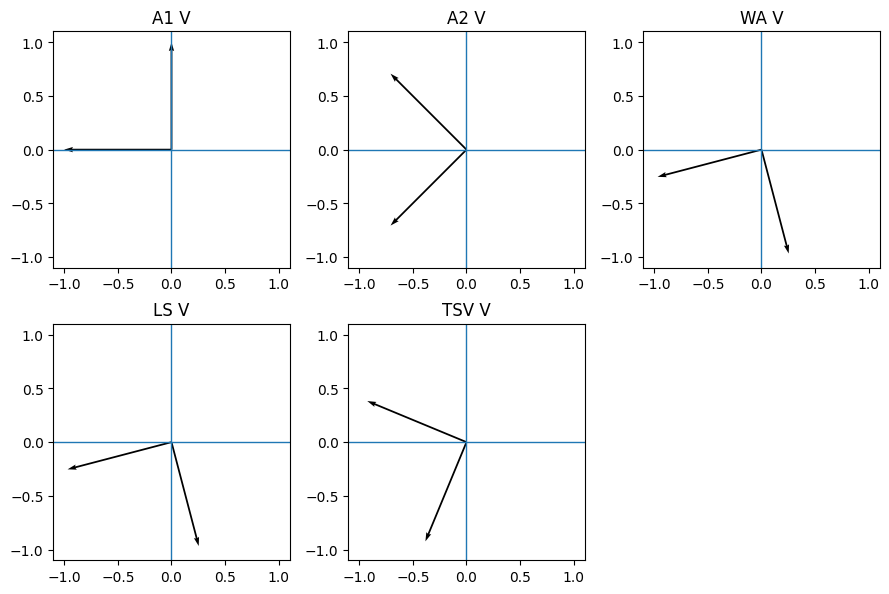

In [18]:
import matplotlib.pyplot as plt
import math
# ----------------------------
# Toy with tunable orthogonality
# ----------------------------
ortho = 0.5                 # 0 = aligned, 1 = orthogonal
theta = ortho * (math.pi/2)

B, Do, Di = 2, 2, 2

v1 = torch.tensor([1.0, 0.0])
v2 = torch.tensor([math.cos(theta), math.sin(theta)])

u1 = torch.tensor([1.0, 1.0]);  u1 = u1 / u1.norm()
u2 = torch.tensor([1.0, -1.0]); u2 = u2 / u2.norm()

s1, s2 = 2.0, 1.5
A1 = s1 * torch.outer(u1, v1)
A2 = s2 * torch.outer(u2, v2)
a_tilde = torch.stack([A1, A2], dim=0)

A_wa  = merge_avg(a_tilde)
A_ls  = merge_lsopt(a_tilde)
A_tsv = merge_tsv(a_tilde)


# ----------------------------
# Plot right singular vectors
# ----------------------------
def right_singular_vecs(A):
    _, _, Vt = torch.linalg.svd(A, full_matrices=False)
    return Vt.T

def plot_right_vecs(ax, A, title):
    V = right_singular_vecs(A)
    ax.axhline(0, linewidth=1); ax.axvline(0, linewidth=1)
    ax.quiver([0,0], [0,0], V[0,:], V[1,:],
              angles='xy', scale_units='xy', scale=1)
    ax.set_aspect('equal', 'box')
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(title)

fig, axs = plt.subplots(2, 3, figsize=(9, 6))
plot_right_vecs(axs[0,0], A1,  "A1 V")
plot_right_vecs(axs[0,1], A2,  "A2 V")
plot_right_vecs(axs[0,2], A_wa,"WA V")
plot_right_vecs(axs[1,0], A_ls,"LS V")
plot_right_vecs(axs[1,1], A_tsv,"TSV V")
axs[1,2].axis("off")
plt.tight_layout()
plt.show()

### Geometric interpretation of TSV

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_56485/1681312568.py:95: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = A @ X_unit_sphere


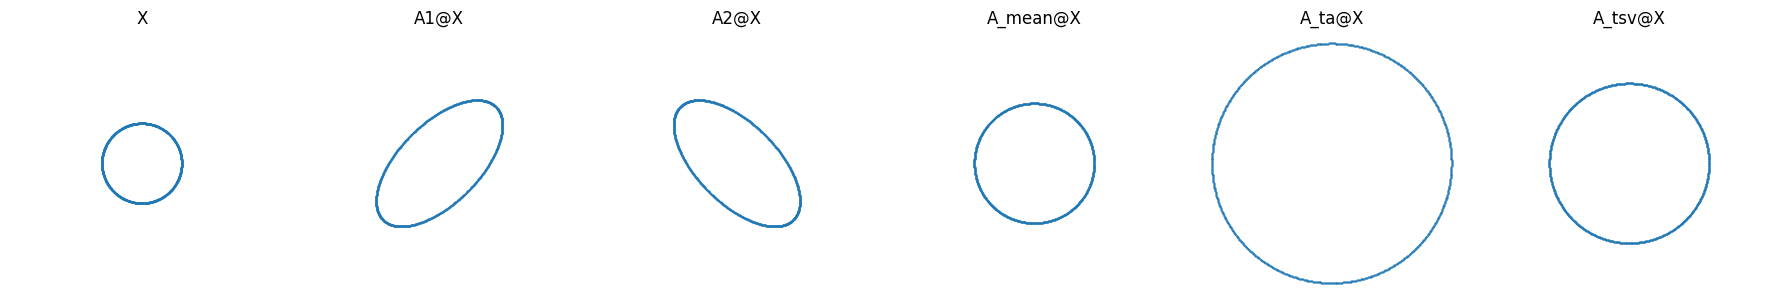

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def rot(deg):
    t = np.deg2rad(deg)
    c, s = np.cos(t), np.sin(t)
    return np.array([[c, -s], [s, c]])

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    """Finds best ortho approx of x

    Args:
        x (torch.Tensor): (Di, Do)

    Returns:
        torch.Tensor: (Di, Do)
    """
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    """Computes the TSV merge of the given tensors.

    Args:
        tensors (torch.Tensor): The tensors to merge. Shape: (N_tasks, Di, Do)

    Returns:
        torch.Tensor: The merged tensors. Shape: (Di, Do)
    """
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    # # # w/o decorrelation
    # tau_bl = torch.einsum("bij,bj,bjk->bik", u, s, vt)
    # tau[layer_name] = tau_bl.sum(dim=0)

    # w/ decorrelation
    B, Di, _ = u.shape
    _, _, Do = vt.shape
    # (Di, B, R)
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)
    u_ortho = compute_procrustes(u_hat)  # (Di, Rp)
    vt_ortho = compute_procrustes(vt_hat.T).T  # (Rp, Do)
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As, r=1):
    # U = np.concatenate([np.linalg.svd(A, full_matrices=False)[0][:, :r] for A in As], axis=1)
    # V = np.concatenate([np.linalg.svd(A, full_matrices=False)[2].T[:, :r] for A in As], axis=1)
    # U, _ = np.linalg.qr(U)
    # V, _ = np.linalg.qr(V)
    # Abar = merge_mean(As)
    # B = U.T @ Abar @ V
    # Ub, s, Vhb = np.linalg.svd(B, full_matrices=False)
    # return U @ (Ub * s) @ Vhb @ V.T
    return get_tsv_merge(torch.stack([torch.from_numpy(A) for A in As]))


# data on unit circle
t = np.linspace(0, 2*np.pi, 800, endpoint=False)
X_unit_sphere = np.stack([np.cos(t), np.sin(t)])

R1, R2 = rot(45), rot(-45)
S = np.diag([2.0, 1.0])
A1 = R1 @ S @ R1.T
A2 = R2 @ S @ R2.T

A_mean = merge_mean([A1, A2])
A_ta = merge_ta([A1, A2])
A_tsv  = merge_tsv([A1, A2], r=1)

mats = [
    ("X", np.eye(2)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A_mean@X", A_mean),
    ("A_ta@X", A_ta),
    ("A_tsv@X", A_tsv),
]

fig, ax = plt.subplots(1, len(mats), figsize=(3*len(mats), 3), sharex=True, sharey=True)
for a, (title, A) in zip(ax, mats):
    Y = A @ X_unit_sphere
    a.plot(Y[0], Y[1], ".", ms=1)
    a.set_title(title); a.set_aspect("equal"); a.axis("off")
plt.tight_layout(); plt.show()


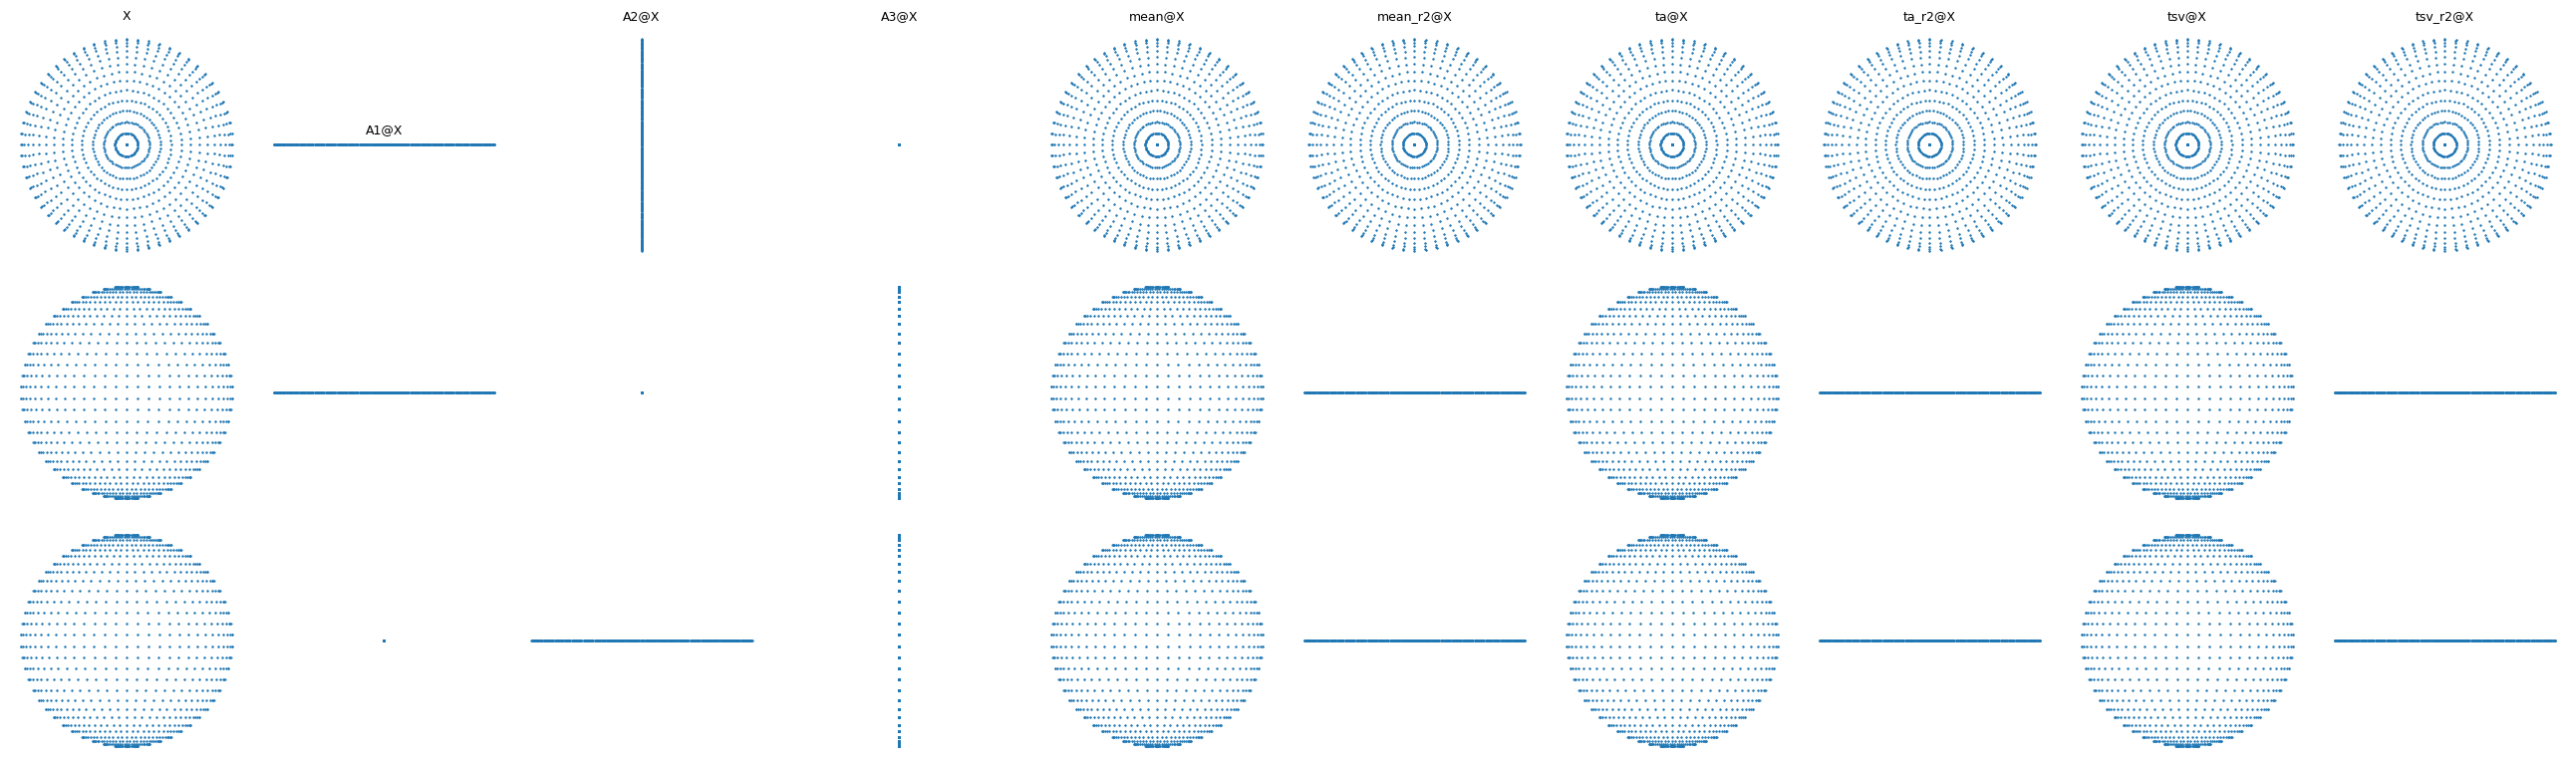

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def merge_mean(As):
    return sum(As) / len(As)

def merge_ta(As):
    return sum(As)

def best_rank_k_np(A, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

def compute_procrustes(x: torch.Tensor) -> torch.Tensor:
    u, _, vt = torch.linalg.svd(x, full_matrices=False)
    return u @ vt

def get_tsv_merge(tensors):
    N_tasks = len(tensors)
    u, s, vt = torch.linalg.svd(tensors, full_matrices=False)
    R = min(u.shape[1], vt.shape[2])
    Rp = R // N_tasks  # rank per task (with full SVD this becomes 1 in 3-task, 3D case)
    u, s, vt = u[:, :, :Rp], s[:, :Rp], vt[:, :Rp, :]

    B, Di, _ = u.shape
    _, _, Do = vt.shape
    u_hat = u.permute(1, 0, 2).reshape(Di, B * Rp)
    s_hat = s.reshape(-1)
    vt_hat = vt.reshape(B * Rp, Do)

    u_ortho = compute_procrustes(u_hat)
    vt_ortho = compute_procrustes(vt_hat.T).T
    tau_l = torch.einsum("ij,j,jk->ik", u_ortho, s_hat, vt_ortho)
    return tau_l

def merge_tsv(As):
    return get_tsv_merge(torch.stack([torch.from_numpy(A).float() for A in As])).numpy()


# =========================
# 🔥 MINIMAL “AHA” CHANGES:
# 1) go to 3D
# 2) use 3 rank-1 “tasks” on different axes
# 3) enforce a rank budget after merging (rank-2)
# 4) visualize via 2D projections (xy, xz, yz)
# =========================

# data on unit sphere in 3D
phi = np.linspace(0, 2*np.pi, 60, endpoint=False)
theta = np.linspace(0, np.pi, 30, endpoint=True)
phi, theta = np.meshgrid(phi, theta)
X_unit_sphere = np.stack([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    np.cos(theta),
]).reshape(3, -1)

# three rank-1-ish maps, orthogonal directions
A1 = np.diag([2.0, 0.0, 0.0])  # stretch x
A2 = np.diag([0.0, 2.0, 0.0])  # stretch y
A3 = np.diag([0.0, 0.0, 2.0])  # stretch z
As = [A1, A2, A3]

A_mean = merge_mean(As)
A_ta   = merge_ta(As)
A_tsv  = merge_tsv(As)

# enforce the same rank budget (this is where WA vs TSV diverge)
k = 2
A_mean_k = best_rank_k_np(A_mean, k)
A_ta_k   = best_rank_k_np(A_ta, k)
A_tsv_k  = best_rank_k_np(A_tsv, k)

mats = [
    ("X", np.eye(3)),
    ("A1@X", A1),
    ("A2@X", A2),
    ("A3@X", A3),

    ("mean@X", A_mean),
    (f"mean_r{k}@X", A_mean_k),

    ("ta@X", A_ta),
    (f"ta_r{k}@X", A_ta_k),

    ("tsv@X", A_tsv),
    (f"tsv_r{k}@X", A_tsv_k),
]

# plot 2D projections: xy, xz, yz
projs = [("xy", (0, 1)), ("xz", (0, 2)), ("yz", (1, 2))]

fig, ax = plt.subplots(
    len(projs), len(mats),
    figsize=(2.6 * len(mats), 2.6 * len(projs)),
    sharex=False, sharey=False
)

for r, (pname, (i, j)) in enumerate(projs):
    for c, (title, A) in enumerate(mats):
        Y = A @ X_unit_sphere
        ax[r, c].plot(Y[i], Y[j], ".", ms=1)
        if r == 0:
            ax[r, c].set_title(title, fontsize=9)
        if c == 0:
            ax[r, c].set_ylabel(pname, rotation=0, labelpad=12, fontsize=10)
        ax[r, c].set_aspect("equal")
        ax[r, c].axis("off")

plt.tight_layout()
plt.show()


### OPT

In [ ]:
import os
import json
from typing import List
import numpy as np
import torch

os.environ["OPENCLIP_CACHEDIR"] = os.environ["SCRATCH"] + "/openclip"


import matplotlib.pyplot as plt
from src.models.task_vectors import NonLinearTaskVector


MODELS_ROOT = os.path.expanduser("models/checkpoints")
# datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
datasets = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
model = "ViT-B-16"
device = "cuda:0"

# Calculate task vectors
task_vectors = []
pretrained_checkpoint = f"{MODELS_ROOT}/{model}/MNISTVal/nonlinear_zeroshot.pt"
for dataset in datasets:
    finetuned_checkpoint = f"{MODELS_ROOT}/{model}/{dataset}Val/nonlinear_finetuned.pt"
    task_vectors.append(
        NonLinearTaskVector(model, pretrained_checkpoint, finetuned_checkpoint)
    )

In [ ]:
# Pull out single matrix
mats = []

for key in task_vectors[0].vector:
    if len(task_vectors[0].vector[key].shape) == 2 and "text_projection" not in key:
        if task_vectors[0].vector[key].min() == task_vectors[0].vector[key].max() == 0:
            continue
        for tv in task_vectors:
            mats.append(tv.vector[key])
        break

mats = torch.stack(mats)

In [ ]:
# Save the mats
torch.save(mats, "results/mats.pt")

In [16]:
import torch
# Load the mats
mats = torch.load("results/mats.pt")
print(mats.shape), mats.min(), mats.max()


torch.Size([6, 197, 768])


(None, tensor(-0.0014), tensor(0.0015))

In [32]:
import numpy as np
def calc_rank(S, norm_thresh=0.95):
    # Rank based on approximation error (Eq. 6) in the paper
    rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)
    return rank

def compute_sar(u, s, mats):

    # figure out effective rank
    rank_eff = calc_rank(s)
    u = u[:, :rank_eff]

    proj_m_w = torch.einsum("ij,jk,bkl->bil", u, u.T, mats)
    return torch.linalg.norm(proj_m_w, ord="fro", dim=(1, 2)) / torch.linalg.norm(mats, ord="fro", dim=(1, 2))  # (b,)


def compute_delta_m_sum(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    return delta_m, u, s

def compute_delta_m_iso(mats):
    delta_m = torch.sum(mats, dim=0)
    u, s, vt = torch.linalg.svd(delta_m, full_matrices=False)
    s_mean = torch.ones_like(s) * s.mean()
    return torch.einsum("ij,j,jk->ik", u, s_mean, vt), u, s

def compute_delta_m_opt(mats):
    delta_t_outers = torch.einsum("bik,bkj->bij", mats, mats.permute(0, 2, 1))
    delta_t_frobs = torch.linalg.norm(mats, ord="fro", dim=(1, 2))[
        :, None, None
    ]
    mat_a = (delta_t_outers / delta_t_frobs).sum(dim=0)
    lam, u = torch.linalg.eig(mat_a)
    return None, u, torch.ones_like(lam)

methods = [
    ("sum", compute_delta_m_sum),
    ("iso", compute_delta_m_iso),
    ("opt", compute_delta_m_opt),
]

rows = []
for method_name, method_fn in methods:
    delta_m, u, s = method_fn(mats)
    sar_m = compute_sar(u, s, mats)
    rows.append({"method": method_name, "sar": sar_m})

/var/folders/r_/d81gvkws1n5fg2_7mb57cwzh0000gn/T/ipykernel_36156/1199381627.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  rank = np.argmax(np.sqrt(np.cumsum(S.pow(2) / S.pow(2).sum())) > norm_thresh)


NotImplementedError: "gt_cpu" not implemented for 'ComplexFloat'

In [28]:
rows

[{'method': 'sum',
  'sar': tensor([0.7909, 0.8007, 0.8295, 0.8179, 0.8240, 0.8547])},
 {'method': 'iso',
  'sar': tensor([0.9549, 0.9521, 0.9563, 0.9526, 0.9525, 0.9568])}]